In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

name = "angel_pc"
DATA_ABSOLUTE_PATH = f"/home/{name}/work/imod-internship/code/data/lifetime/nv-center/superk/"

In [17]:
def read_text_file(file_path):
    # Read the text file
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Extract the column headers from the first line
    column_headers = lines[0].strip().split('\t')
    
    # Create a list to store the data
    data = []
    
    # Process each line in the text file (excluding the first line)
    for line in lines[1:]:
        # Split the line into columns using tabs as the delimiter
        columns = [int(i) for i in line.strip().split('\t')]

        # Append the columns to the data list
        data.append(columns)
    
    # Create a pandas dataframe from the data and set the column headers
    df = pd.DataFrame(data, columns=column_headers)
    
    return df

In [45]:
# function to draw graph, if you want multiple data sets drawn on the same graph
# set render equal to False on all your plot_data() calls up until the last one.
def plot_data(x, y, line_name, x_label, y_label, fmt_str='', render=True):
    # Refer to docs for more info on fmt -> https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.plot.html
    plt.plot(x, y, fmt_str, label=line_name) if fmt_str else plt.plot(x, y, label=line_name)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    if (render):
        # sorry no time for proper implementation, if you want to save the graph to your pc
        # uncomment safefig line and hard code file path
        # plt.savefig(f"/home/{name}/windows-school/nv_true_bi_data.png", bbox_inches="tight")
        plt.show()


In [19]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def fit_gaussian(x, y):
    
    p0 = [np.max(y), np.mean(x), np.std(x)]  # Initial guess for the parameters
    
    # Fit the Gaussian curve to the data
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)
    return popt, pcov

    "Time (ps)"  "Counts per bin"
0             0               597
1          1000             77120
2          2000            935716
3          3000             36188
4          4000              1484
5          5000               611
6          6000               564
7          7000               526
8          8000               467
9          9000               516
10        10000               544
11        11000               500
std is 0.417


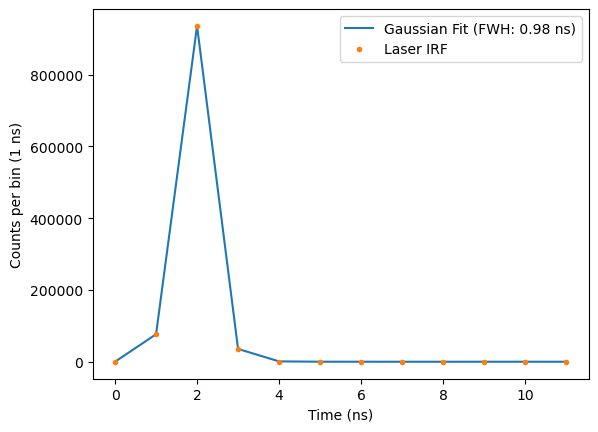

In [20]:
IRF_data_file_name_50_bins = "Histogram_2025-08-05_115039_IRF_50.txt"
IRF_data_file_name_12_bins = "Histogram_2025-08-05_115233_IRF_12_superk.txt"
# df = read_text_file('2024_02_15/laser_si.txt')
# df = read_text_file('/home/angel/work/imod-internship/code/data/lifetime/tommy-lifetime/laser_si.txt') # not relevant to this notebook, disregard
df = read_text_file(f"/home/{name}/work/imod-internship/code/data/lifetime/{IRF_data_file_name_12_bins}")
print(df)

x = df.values[:, 0] / 1000
y = df.values[:, 1]
popt, pcov = fit_gaussian(x, y)
print('std is %.3f' %popt[2])
fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]

x_label = "Time (ns)"
y_label = "Counts per bin (1 ns)"
data_label = "Laser IRF"
fit_label = f"Gaussian Fit (FWH: {fwhm*1:.2f} ns)"
plot_data(x, y, fit_label, x_label, y_label, render=False)
plot_data(x, gaussian(x, *popt), data_label, x_label, y_label, fmt_str=".")

In [21]:
# reads in multiple files and sums the counts per bin across files
def read_multiple_text_files(file_paths):
    a = []
    b = []
    l = len(file_paths)
    # Process each file in the list 
    c = False
    for file_path in file_paths:
        d = read_text_file(file_path)
        if c == False:
            # a = d.values[180:, 0]/1000
            a = d.values[:, 0]/1000
            # b = d.values[180:, 1]
            b = d.values[:, 1]
            c = True
        else:
            # b += d.values[180:, 1]
            b += d.values[:, 1]
    return a,b,l

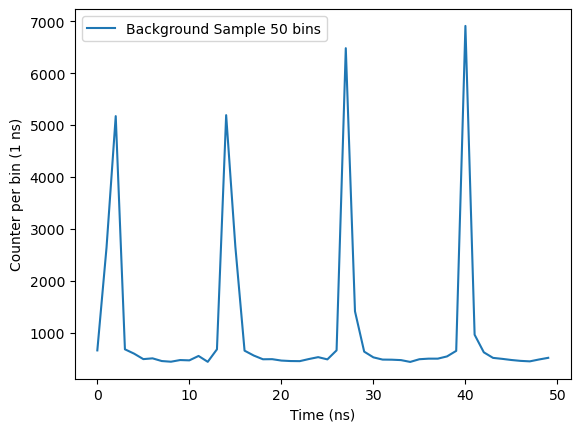

In [32]:
# for off sample 50 bins (bkg)
bkg_data_file_name_50_bins = "Histogram_2025-08-05_111643_bkg_50.txt"
# times, cts, num_files = read_multiple_text_files(['/Users/tommtommbom/Desktop/qdrepos/Data/20240827/530_30_bp_in_blankspot_1.5uW.txt'])
# times, cts, num_files = read_multiple_text_files(['/home/angel/work/imod-internship/code/data/lifetime/tommy-lifetime/530_30_bp_in_blankspot_1.5uW.txt'])
times_50, cts_50, num_files_50 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{bkg_data_file_name_50_bins}"])

data_label_50 = "Background Sample 50 bins"
x_label = "Time (ns)"
y_label = "Counter per bin (1 ns)"
plot_data(times_50, cts_50, data_label_50, x_label, y_label)

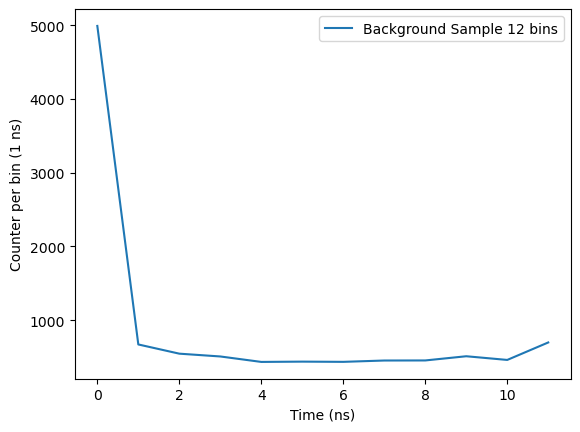

In [34]:
# off sample 50 bins (bkg)
bkg_data_file_name_12_bins = "Histogram_2025-08-05_111814_bkg_12.txt"

times_12, cts_12, num_files_12 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{bkg_data_file_name_12_bins}"])

data_label_12 = "Background Sample 12 bins"
x_label = "Time (ns)"
y_label = "Counter per bin (1 ns)"
plot_data(times_12, cts_12, data_label_12, x_label, y_label)

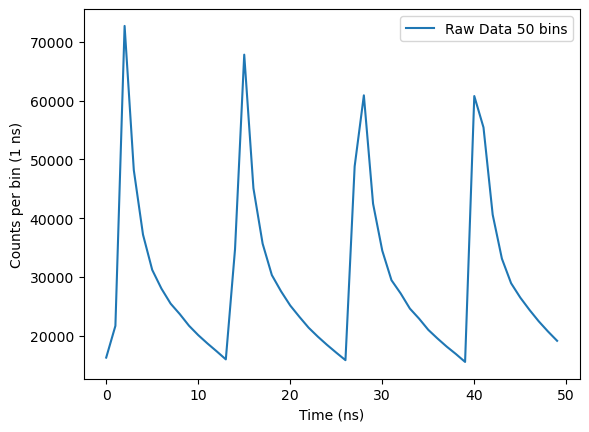

In [38]:
# dot1 = ['2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_164853.txt', '2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_170058.txt', '2024_02_16/undoped_sio2/dot1/Histogram_2024-02-16_171116.txt']
# dot2 = ['2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_182027.txt', '2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_205912.txt', '2024_02_16/undoped_sio2/dot2/Histogram_2024-02-16_211208.txt']
# dot3 = ['2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_212316.txt', '2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_213333.txt','2024_02_16/undoped_sio2/dot3/Histogram_2024-02-16_214354.txt']
# dot1 = ['/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_164853.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_170058.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot1/Histogram_2024-02-16_171116.txt']
# dot2 = ['/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_182027.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_205912.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot2/Histogram_2024-02-16_211208.txt']
# dot3 = ['/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_212316.txt', '/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_213333.txt','/home/angel/work/imod-internship/code/data/dotdata/dot3/Histogram_2024-02-16_214354.txt']
data_file_name_50_bins = "Histogram_2025-08-05_110652_data_50.txt"
times_nv_50, cts_nv_50, num_files_nv_50 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{data_file_name_50_bins}"])

data_label_50 = "Raw Data 50 bins"
x_label = "Time (ns)"
y_label = "Counts per bin (1 ns)"
plot_data(times_nv_50, cts_nv_50, data_label_50, x_label, y_label)

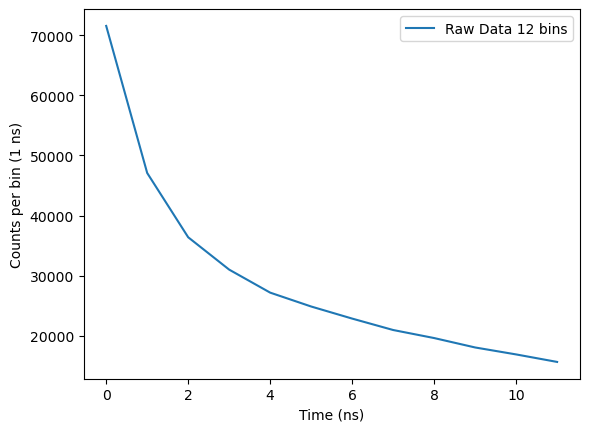

In [40]:
data_file_name_12_bins = "Histogram_2025-08-05_111106_data_12_nodeadtime.txt"

times_nv_12, cts_nv_12, num_files_nv_12 = read_multiple_text_files([f"{DATA_ABSOLUTE_PATH}{data_file_name_12_bins}"])

data_label_12 = "Raw Data 12 bins"
x_label = "Time (ns)"
y_label = "Counts per bin (1 ns)"
plot_data(times_nv_12, cts_nv_12, data_label_12, x_label, y_label)

lifetime is : 6.45 ns


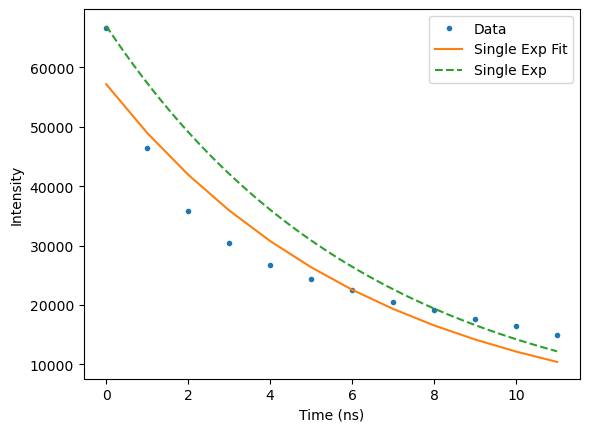

In [42]:
true_cts = cts_nv_12 - cts_12

def single_exponential(x, amplitude, lifetime):
    return amplitude * np.exp(-x/lifetime)

def fit_single_exponential(x, y):
    amplitude_0 = 67000
    lifetime_0 = 13
    p0 = [amplitude_0, lifetime_0]
    popt, pcov = curve_fit(single_exponential, x, y, p0=p0, maxfev=10000, gtol = 1e-10)
    return popt, pcov

popt, pcov = fit_single_exponential(times_nv_12, true_cts)
lifetime_single = popt[1]
print(f"lifetime is : {lifetime_single:.2f} ns")

x_label = "Time (ns)"
y_label = "Intensity"
data_label = "Data"
fit_label = "Single Exp Fit"
plot_data(times_nv_12, true_cts, data_label, x_label, y_label, fmt_str=".", render=False)
plot_data(times_nv_12, single_exponential(times_nv_12, *popt), fit_label, x_label, y_label, render=False)

amplitude = 67000
t_fit = np.linspace(0, 11, 100)
y_single = single_exponential(t_fit, amplitude, lifetime_single)
single_exp_label = "Single Exp"
plot_data(t_fit, y_single, single_exp_label, x_label, y_label, fmt_str="--")

lifetime is : 13.19 ns
Second lifetime: 1.22 ns


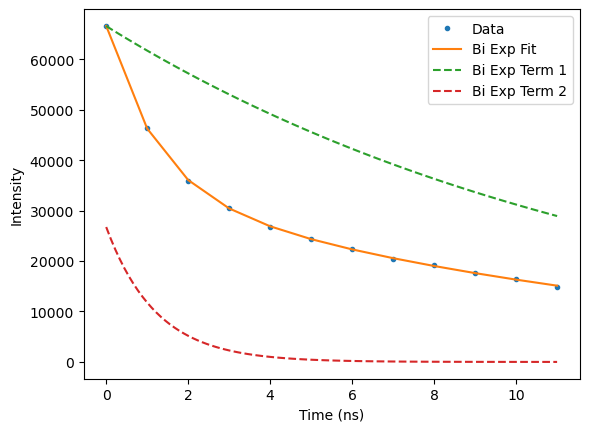

In [46]:
true_cts = cts_nv_12 - cts_12
#true_cts = true_cts - min(true_cts) # normalize counts #PLAY WITH THIS, comment in and out to see what looks better
# true_cts = true_cts/max(true_cts) # normalize counts
from scipy import special

def bi_exponential(x, amplitude_1, lifetime_1, amplitude_2, lifetime_2):
    return amplitude_1 * np.exp(-x/lifetime_1) + amplitude_2 * np.exp(-x/lifetime_2)

def fit_biexponential(x, y):
    amplitude_1_0 = 67000
    lifetime_1_0 = 13
    amplitude_2_0 = 26000
    lifetime_2_0 = 1
    p0 = [amplitude_1_0, lifetime_1_0, amplitude_2_0, lifetime_2_0]
    
    popt, pcov = curve_fit(bi_exponential, x, y, p0=p0, maxfev=10000, gtol = 1e-10)
    return popt, pcov

popt, pcov = fit_biexponential(times_nv_12, true_cts)
lifetime_bi_1 = popt[1]
lifetime_bi_2 = popt[3]
print(f"lifetime is : {lifetime_bi_1:.2f} ns")
print(f"Second lifetime: {lifetime_bi_2:.2f} ns")


x_label = "Time (ns)"
y_label = "Intensity"

data_label = "Data"
fit_label = "Bi Exp Fit"
plot_data(times_nv_12, true_cts, data_label, x_label, y_label, fmt_str=".", render=False)
plot_data(times_nv_12, bi_exponential(times_nv_12, *popt), fit_label, x_label, y_label, render=False)

amplitude_1 = 66574
amplitude_2 = 26742
t_fit = np.linspace(0, 11, 100)
y_bi_term1 = single_exponential(t_fit, amplitude_1, lifetime_bi_1)
y_bi_term2 = single_exponential(t_fit, amplitude_2, lifetime_bi_2)
bi_term1_label = "Bi Exp Term 1"
bi_term2_label = "Bi Exp Term 2"
plot_data(t_fit, y_bi_term1, bi_term1_label, x_label, y_label, fmt_str="--", render=False)
plot_data(t_fit, y_bi_term2, bi_term2_label, x_label, y_label, fmt_str="--")